In [1]:
# OPTIONAL: run once in a fresh Colab runtime; skip during local development.
INSTALL_COLAB_PACKAGES = False  # Set to True to install; reset to False afterward.

import sys
import subprocess

# Detect Colab; otherwise use the local .venv.
try:
    from google.colab import output
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if not IN_COLAB:
    print("Local environment: skipped. Use uv sync --group llm in your terminal.")
elif not INSTALL_COLAB_PACKAGES:
    print("Installation skipped. Set INSTALL_COLAB_PACKAGES = True if this is a fresh Colab runtime.")
else:
    if sys.version_info[:2] != (3, 13):
        raise RuntimeError("Choose a Python 3.13 Colab runtime before installing these packages.")
    # Install into the Python running these cells.
    subprocess.check_call([sys.executable, "-m", "pip", "install", "uv>=0.8,<1"])
    packages = [
        "ipython>=8,<9",
        "matplotlib-inline<0.2",
        "pandas>=2.0",
        "numpy>=1.24",
        "scikit-learn>=1.3",
        "fairlearn>=0.10",
        "matplotlib>=3.7",
        "jupyter>=1.0",
        "shap>=0.44"
    ]
    subprocess.check_call([sys.executable, "-m", "uv", "pip", "install",
                           "--python", sys.executable, *packages])
    print("Installation finished. Choose Runtime → Restart session before continuing.")

Installation finished. Choose Runtime → Restart session before continuing.


# Défi ÉquiAlgo : modèle corrigé

Cette démarche est très fortement inspirée et adatée de l'exemple "Credit Loans Decisions" de la documentation de Fairlearn (https://fairlearn.org/v0.14/auto_examples/plot_credit_loan_decisions.html).

Ce carnet implemente notre solution d'attenuation, avec un graphique du front de Pareto par balayage de la contrainte, et compare le modèle en production à notre modèle corrigé.

Maintenant que nous avons identifié les torts potentiellement causés, nous pouvons définir nos métriques d'équité. En plus de ces métriques, nous allons quantifier l'incertitude autour de chaque métrique en utilisant des fonctions qui calculent l'écart-type de chaque métrique à un niveau de confiance de alpha=0,95.

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix
from fairlearn.metrics import (
    MetricFrame,
    count,
    selection_rate,
    false_negative_rate,
    false_positive_rate,
    equalized_odds_difference,
)


demandes = pd.read_csv('data/donnees_demandes.csv')
candidats = pd.read_csv('data/candidats_evaluation.csv')

def compute_error_metric(metric_value, sample_size):
    """Compute standard error of a given metric based on the assumption of
    normal distribution.

    Parameters:
    metric_value: Value of the metric
    sample_size: Number of data points associated with the metric

    Returns:
    The standard error of the metric
    """
    metric_value = metric_value / sample_size
    return 1.96 * np.sqrt(metric_value * (1.0 - metric_value)) / np.sqrt(sample_size)

def false_negative_error(y_true, y_pred):
    """Compute the standard error for the false negative rate estimate."""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return compute_error_metric(tp, fn + tp)

def false_positive_error(y_true, y_pred):
    """Compute the standard error for the false positive rate estimate."""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return compute_error_metric(fp, fp + tn)

def accuracy_error(y_true, y_pred):
    """Compute the standard error for the precision estimate."""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return compute_error_metric(tp + tn, tn + fp + fn + tp)

fairness_metrics = {
    "count": count,
    "accuracy": accuracy_score,
    "acurracy_error": accuracy_error,
    "selection_rate": selection_rate,
    "false_negative_rate": false_negative_rate,
    "false_negative_error": false_negative_error,
    "false_positive_rate": false_positive_rate,
    "false_positive_error": false_positive_error,
}

metrics_to_report = [
    "accuracy",
    "false_negative_rate",
    "false_positive_rate",
]


Pour calculer les métriques de performance désaggrégées, nous allons utiliser l'objet `MetricFrame` de la librairie Fairlearn. Nous allons fournir notre dictionnaire de métriques `fairness_metrics` ainsi que nos étiquettes de test `y_test` et les prédictions de test `y_pred`.

De plus, nous fournissons les caractéristiques sensibles `groupe_test` pour désaggréger les résultats de notre modèle.


In [37]:
# Reprenons le modele de base pour le comparer.
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

demandes = pd.read_csv('data/donnees_demandes.csv')
candidats = pd.read_csv('data/candidats_evaluation.csv')

# Les cinq regions administratives presentes dans le jeu de donnees.
ELOIGNEES = ['Bas-Saint-Laurent', 'Cote-Nord', 'Gaspesie-Iles-de-la-Madeleine']

def groupe_region(df):
    """Regroupe les cinq regions en deux blocs : grands centres / regions eloignees."""
    return np.where(df['region_administrative'].isin(ELOIGNEES), 'Eloignee', 'Centre')

par_region = demandes.groupby('region_administrative').agg(
    candidats=('decision_octroi', 'size'),
    taux_octroi=('decision_octroi', 'mean'),
    cote_r_moyenne=('cote_r_equivalent', 'mean'),
).sort_values('taux_octroi')
print(par_region.round(3))

demandes['groupe'] = groupe_region(demandes)

CATEGORIELLES = ['programme_etudes', 'region_administrative', 'code_postal_3']
def encoder(df_entrainement, df_cible):
    """Encode les colonnes categorielles et aligne les colonnes des deux tableaux.

    L'alignement (reindex) est important : si une categorie est absente d'un des
    deux jeux, get_dummies produit un nombre de colonnes different et le modele
    echoue - ou pire, apprend sur les mauvaises colonnes.
    """
    X = pd.get_dummies(
        df_entrainement.drop(columns=['id_candidat', 'decision_octroi', 'groupe'], errors='ignore'),
        columns=CATEGORIELLES,
    )
    Xc = pd.get_dummies(
        df_cible.drop(columns=['id_candidat', 'decision_octroi', 'groupe'], errors='ignore'),
        columns=CATEGORIELLES,
    ).reindex(columns=X.columns, fill_value=0)
    return X, Xc
train, test = train_test_split(
    demandes, test_size=0.3, random_state=42, stratify=demandes['decision_octroi']
)
X_train, X_test = encoder(train, test)
y_train, y_test = train['decision_octroi'], test['decision_octroi']

modele = RandomForestClassifier(n_estimators=300, min_samples_leaf=20, random_state=42)
modele.fit(X_train, y_train)
y_pred = modele.predict(X_test)

                               candidats  taux_octroi  cote_r_moyenne
region_administrative                                                
Cote-Nord                           1178        0.263          27.325
Bas-Saint-Laurent                   1293        0.269          27.296
Gaspesie-Iles-de-la-Madeleine       1529        0.284          27.354
Montreal                            4001        0.483          27.988
Capitale-Nationale                  1999        0.484          27.984


In [38]:
# Comparons maintenant avec nos metriques
groupe_test = groupe_region(test)

metricframe_unmitigated = MetricFrame(
    metrics=fairness_metrics,
    y_true=y_test,
    y_pred=y_pred,
    sensitive_features=groupe_test,
)

metricframe_unmitigated.by_group[metrics_to_report]

metricframe_unmitigated.difference()[metrics_to_report]

metricframe_unmitigated.overall[metrics_to_report]

,0
accuracy,0.881333
false_negative_rate,0.170284
false_positive_rate,0.084351


In [39]:
def plot_group_metrics_with_error_bars(metricframe, metric, error_name):
    """Plot the disaggregated metric for each group with an associated
    error bar. Both metric and the error bar are provided as columns in the
    provided MetricFrame.

    Parameters
    ----------
    metricframe : MetricFrame
        The MetricFrame containing the metrics and their associated
        uncertainty quantification.
    metric : str
        The metric to plot
    error_name : str
        The associated standard error for each metric in metric

    Returns
    -------
    Matplotlib Plot of point estimates with error bars
    """
    grouped_metrics = metricframe.by_group
    point_estimates = grouped_metrics[metric]
    error_bars = grouped_metrics[error_name]
    lower_bounds = point_estimates - error_bars
    upper_bounds = point_estimates + error_bars

    x_axis_names = [str(name) for name in error_bars.index.to_flat_index().tolist()]
    plt.vlines(
        x_axis_names,
        lower_bounds,
        upper_bounds,
        linestyles="dashed",
        alpha=0.45,
    )
    plt.scatter(x_axis_names, point_estimates, s=25)
    plt.xticks(rotation=0)
    y_start, y_end = np.round(min(lower_bounds), decimals=2), np.round(
        max(upper_bounds), decimals=2
    )
    plt.yticks(np.arange(y_start, y_end, 0.05))
    plt.ylabel(metric)

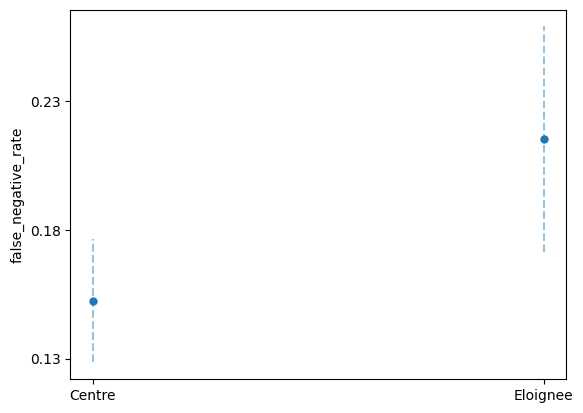

In [40]:
plot_group_metrics_with_error_bars(
    metricframe_unmitigated, "false_negative_rate", "false_negative_error"
)

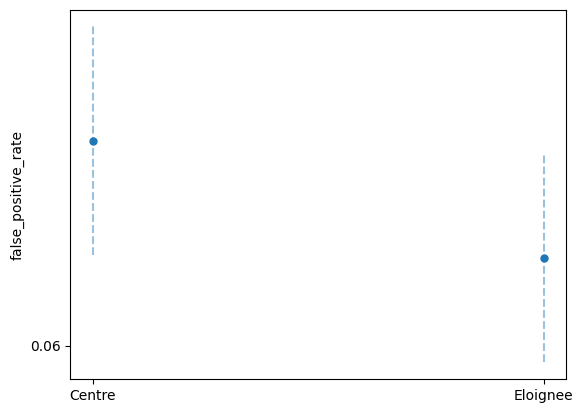

In [41]:
plot_group_metrics_with_error_bars(
    metricframe_unmitigated, "false_positive_rate", "false_positive_error"
)

array([[<Axes: title={'center': 'accuracy'}, xlabel='sensitive_feature_0'>,
        <Axes: title={'center': 'false_negative_rate'}, xlabel='sensitive_feature_0'>,
        <Axes: title={'center': 'false_positive_rate'}, xlabel='sensitive_feature_0'>]],
      dtype=object)

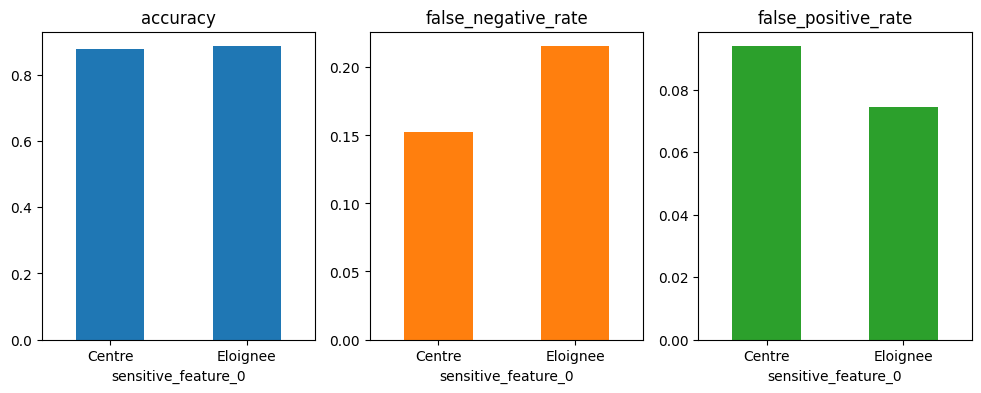

In [42]:
metricframe_unmitigated.by_group[metrics_to_report].plot.bar(
    subplots=True, layout=[1, 3], figsize=[12, 4], legend=None, rot=0
)

Finalement, on peut calculer la différence de cote égalisée pour ce modèle biaisé non atténué. La différence de cote égalisée dans notre cas est le maximum de la différence du taux de faux négatifs (recall) et de celle du taux de faux positifs.

Dans notre contexte d'octroi de bourse, les disparités des taux de faux négatifs et de faux positifs causent toutes les deux des torts d'équité, puisque les personnes habitant loin des centres qui auraient dû obtenir une bourse peuvent ressentir un sentiment d'injustice face aux personnes habitant dans les centres qui ont reçu une bourse alors qu'ils n'en avaient pas besoin.

C'est pourquoi nous essayons de minimiser ces deux métriques en minimisant la différence de cote égalisée.

In [43]:
accuracy_unmitigated = accuracy_score(y_test, y_pred)
equalized_odds_unmitigated = equalized_odds_difference(y_test, y_pred, sensitive_features=groupe_test)

Ici, une hypothèse clé est que nous supposons que les faux négatifs et les faux positifs ont tous les deux ont un impact négatif similaire sur les deux groupes.

Puisque le taux d'octroi de bourse est une contrainte fixe (entre 36% et 44%), il s'agit d'un cas "zero-sum game", c'est-à-dire qu'octroyer la bourse à une personne revient nécessairement à ne pas l'octroyer à une autre personne.

## Atténuation du biais du modèle de base

Nous venons d'identifier des disparités dans la performance du modèle selon la provenance des candidats. En particulier, nous avons trouvé que le modèle produit des taux de faux négatifs et de faux positifs siginificativement plus grands pour les candidats provenant des centres que pour ceux des candidats des régions éloignées. Dans ce contexte de décision d'octroi de bourse de mérite, cela signifie que le modèle sous-alloue des bourses aux candidats des régions éloignées qui auraient dû autrement la mériter, mais sur-alloue des bourses aux candidats des centres qui n'auraient pas autrement mérité la bourse.

Dans cette section, nous allons implémenter deux stratégies pour atténuer les disparités de performance trouvées dans notre modèle de base. Les deux stratégies sont les suivantes:

 - Post-traitement: puisque nous avons une variable sensible (la région administrative), les décisions de notre classifieur peuvent être transformées pour satisfaire une contrainte d'équité donnée.

 - Réductions: dans cette approche, nous prenons une classe de modèle et créons une séquence de modèles qui optimise de manière itérative une contrainte d'équité donnée.

 Comparée à l'approche de post-traitement, la contrainte d'équité est satisfaite pendant l'entraînement du modèle plutôt qu'après.

# Atténutation post-traitement: ThresholdOptimizer

Dans la libraire Fairlearn, l'atténutation post-traitement est faite par l'algorithme `ThresholdOptimizer`, selon Hardt, Price, and Srebro. Le
`ThresholdOptimizer` prend un modèle d'apprentissage automatique existant (possiblement déjà ajusté) dont les prédictions agissent en tant que fonction de score pour identifier des seuils distincts pour chaque groupe de caractéristiques sensibles. Le `ThresholdOptimizer` optimise une métrique d'objectif spécifique (dans notre cas le rappel, ce qui équivaut à 1 - taux de faux négatifs) sujet à une contrainte d'équité donnée (cote égalisée), ce qui donne une seuillée du modèle d'apprentissage automatique sous-jacent.

Pour instancier notre `ThresholdOptimizer`, nous avons besoin de spécifier notre contrainte d'équité comme paramètre du modèle. Puisque les disparités de rappel et de faux positifs résultent tous les deux en des torts réels dans notre scénario, nous visons à utiliser la minimisation de la différence de cotes égalisées comme contrainte d'équité.

In [44]:
from fairlearn.postprocessing import ThresholdOptimizer

postprocess_est = ThresholdOptimizer(
    estimator=modele,
    constraints="equalized_odds",  # Optimize TPR and FPR simultaneously
    objective="accuracy_score",
    prefit=True,
    predict_method="predict_proba",
)

In [45]:
groupe_train = groupe_region(train)
postprocess_est.fit(X=X_train, y=y_train, sensitive_features=groupe_train)

postprocess_pred = postprocess_est.predict(X_test, sensitive_features=groupe_test)

postprocess_pred_proba = postprocess_est._pmf_predict(X_test, sensitive_features=groupe_test)

# Audit d'équité du modèle post-traité

In [46]:
def compare_metricframe_results(mframe_1, mframe_2, metrics, names):
    """Concatenate the results of two MetricFrames along a subset of metrics.

    Parameters
    ----------
    mframe_1: First MetricFrame for comparison
    mframe_2: Second MetricFrame for comparison
    metrics: The subset of metrics for comparison
    names: The names of the selected metrics

    Returns
    -------
    MetricFrame : MetricFrame
        The concatenation of the two MetricFrames, restricted to the metrics
        specified.

    """
    return pd.concat(
        [mframe_1.by_group[metrics], mframe_2.by_group[metrics]],
        keys=names,
        axis=1,
    )

In [47]:
accuracy_postprocess = accuracy_score(y_test, postprocess_pred)
eq_odds_postprocess = equalized_odds_difference(
    y_test, postprocess_pred, sensitive_features=groupe_test
)

metricframe_postprocess = MetricFrame(
    metrics=fairness_metrics,
    y_true=y_test,
    y_pred=postprocess_pred,
    sensitive_features=groupe_test,
)

metricframe_postprocess.overall[metrics_to_report]

metricframe_postprocess.difference()[metrics_to_report]

,0
accuracy,0.003438
false_negative_rate,0.002909
false_positive_rate,0.025161


Maintenant, comparons la performance de notre classifieur seuillé avec le modèle de base.

array([[<Axes: title={'center': 'accuracy'}, xlabel='sensitive_feature_0'>,
        <Axes: title={'center': 'false_negative_rate'}, xlabel='sensitive_feature_0'>,
        <Axes: title={'center': 'false_positive_rate'}, xlabel='sensitive_feature_0'>]],
      dtype=object)

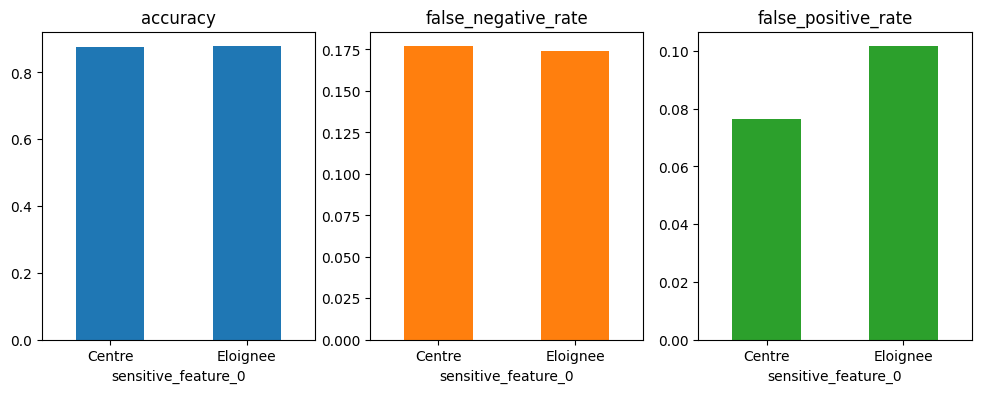

In [48]:
compare_metricframe_results(
    metricframe_unmitigated,
    metricframe_postprocess,
    metrics=metrics_to_report,
    names=["Unmitigated", "PostProcess"],
)

metricframe_postprocess.by_group[metrics_to_report].plot.bar(
    subplots=True, layout=[1, 3], figsize=[12, 4], legend=None, rot=0
)

On observe que l'algorithme de `ThresholdOptimizer` obtient une disparité bien plus basse entre les deux groupes par rapport au modèle de base.

# Approche de réductions d'atténuation d'inéquités

Dans cette section, nous allons utiliser une approche de réductions proposée par Agarwal et. al (2018) pour produire des modèles qui satisfont la contrainte d'équité sans avoir besoin d'accéder à des variables sensibles au moment du déploiement du modèle.

L'algorithme de réduction principal de Fairlearn est `ExponentiatedGradient`. L'algorithme crée une séquence de jeux de données repesés et réentraîne le classifieur sur chacun des jeux de données. Ce réentraînement garantie de trouver un modèle qui satisfait les contraintes d'équité tout en optimisant la métrique de performance.

Le modèle obtenu par `ExponentiatedGradient` consiste en plusieurs modèles internes, retournés dans un estimator enveloppé.

Pour instancier un modèle `ExponentiatedGradient`, nous utilisons deux paramètres:
 - un estimateur de base (objet qui supporte l'entraînement)
 - des contraintes d'équité (objet de type fairlearn.reductions.Moment)

En passant

When passing in a fairness constraint as a Moment, we can specify an epsilon value representing the maximum allowed difference or ratio between our largest and smallest value. For example, in the below code, EqualizedOdds(difference_bound=epsilon) means that we are using EqualizedOdds as our fairness constraint, and we will allow a maximal difference of epsilon between our largest and smallest equalized odds value.